In [36]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os


In [37]:
load_dotenv()



api_key = os.getenv("GROQ_API_KEY")

subgraph_llm  = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=api_key
)

In [38]:
class Substate(TypedDict):

    input_text : str
    translated_text : str



In [39]:
def translate_text(state: Substate):

    prompt = f"""
Translate the following text to Bangla.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [40]:

subgraph_builder = StateGraph(Substate)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [41]:

class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [42]:
parent_llm = subgraph_llm

In [43]:

def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [44]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [ ]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

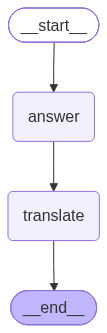

In [47]:
graph = parent_builder.compile()

graph

In [ ]:
result = graph.invoke({'question': 'What is quantum physics'})

result["answer_hin"]

In [ ]:
print(result["answer_hin"])

"**কোয়ান্টাম পদার্থবিজ্ঞান (যা কোয়ান্টাম মেকানিক্স বা কোয়ান্টাম তত্ত্ব নামেও পরিচিত) হল পদার্থবিজ্ঞানের সেই শাখা যা পদার্থ ও শক্তি সবচেয়ে ছোট স্কেলে—সাধারণত পরমাণু, ইলেকট্রন, ফোটন এবং অন্যান্য মৌলিক কণার স্তরে—কীভাবে আচরণ করে তা বর্ণনা করে।**  \n\nএই স্কেলে দৈনন্দিন “ক্লাসিকাল” পদার্থবিজ্ঞানের নিয়ম (নিউটনের সূত্র, ম্যাক্সওয়েলের সমীকরণ ইত্যাদি) আর সঠিক পূর্বাভাস দেয় না। পরিবর্তে, প্রকৃতি এমন কিছু নীতি অনুসরণ করে যা মূলত সম্ভাব্যতাবাদী এবং প্রায়ই বোধগম্যতার বাইরে। কোয়ান্টাম পদার্থবিজ্ঞানের মূল ধারণাগুলো হল:\n\n| নীতি | অর্থ | দৈনন্দিন তুলনা (যদি থাকে) |\n|-----------|--------------|---------------------------|\n| **কোয়ান্টাইজেশন** | কিছু শারীরিক পরিমাণ (যেমন শক্তি, কৌণিক গতি) শুধুমাত্র বিচ্ছিন্ন মানই নিতে পারে, যেন সিঁড়ির ধাপে ধাপে। | নীয়ন সাইন থেকে বের হওয়া আলো “ফোটন” আকারে—অবিভাজ্য শক্তির প্যাকেট, মসৃণ প্রবাহ নয়। |\n| **তরঙ্গ‑কণিকা দ্বৈততা** | ইলেকট্রন ও ফোটনের মতো কণাগুলো পরিমাপের পদ্ধতির উপর নির্ভর করে তরঙ্গ‑সদৃশ ও কণিকা‑সদৃশ বৈশিষ্ট্য উভয়ই দেখায়। | ডাবল‑স্লিট পরীক্ষা